# Module 8: LDA with SciKit Learn

* DS 5001
* Clay Harris

# Set Up

## Configs

In [1]:
n_terms = 4000
n_topics = 30
max_iter = 5
OHCO = ['genre', 'author', 'book', 'chapter', 'para_num']
src_corpus =  'novels-TOKEN.csv'

## Imports

In [2]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA

In [3]:
%matplotlib inline

# Prepare Data

## Convert TOKENS to table of paragraphs

Scikit Learn wants an F1 style corpus. We create onefrom our annotated TOKEN table, keeping only regular nouns.

In [4]:
TOKENS = pd.read_csv(src_corpus)
PARAS = TOKENS[TOKENS.pos.str.match(r'^NNS?$')]\
    .groupby(OHCO).term_str\
    .apply(lambda x: ' '.join(x))\
    .to_frame()\
    .rename(columns={'term_str':'para_str'})

In [5]:
PARAS.head()

para_str
genre author   book            chapter para_num                                                   
d     christie secretadversary 1       1                                                     thing
                                       2                                                      bean
                                       3         people affectionately exit so old misleading a...
                                       4                             not man bun me bit gangway it
                                       5                                    girl assenting towards

## Create Vector Space

We use Scikit Learn's CountVectorizer to convert our F1 corpus of paragraphs into a document-term vector space of word counts.

In [6]:
tfv = CountVectorizer(max_features=n_terms, stop_words='english')
tf = tfv.fit_transform(PARAS.para_str)
TERMS = tfv.get_feature_names_out()

# Generate Model

We run Scikit Learn's [LatentDirichletAllocation algorithm](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.LatentDirichletAllocation.html#sklearn.decomposition.LatentDirichletAllocation) and extract the THETA and PHI tables.

In [7]:
lda = LDA(n_components=n_topics, max_iter=max_iter, learning_offset=50., random_state=0)

## THETA

In [8]:
THETA = pd.DataFrame(lda.fit_transform(tf), index=PARAS.index)
THETA.columns.name = 'topic_id'

In [9]:
THETA.sample(20).style.background_gradient()

## PHI

In [10]:
PHI = pd.DataFrame(lda.components_, columns=TERMS)
PHI.index.name = 'topic_id'
PHI.columns.name  = 'term_str'

In [11]:
PHI.T.head().style.background_gradient()

topic_id,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
term_str,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
abbess,2.173618,0.033341,0.033333,0.033333,0.033333,4.950702,0.033334,1.564709,0.033333,0.033333,0.033333,3.602291,0.037568,0.033333,0.033333,0.033896,0.033333,5.892649,0.033333,42.482251,0.033333,0.033333,0.033333,0.033333,1.365287,0.033333,0.033333,0.033333,0.033333,2.230355
abbey,2.000325,0.033333,0.033333,0.033333,0.033333,0.033333,0.033337,13.101679,0.033333,1.123864,6.822906,0.033333,1.728371,0.033333,3.993440,0.420613,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.379695,0.033333,0.033333,3.543190,0.033333,0.033333,0.033333,7.219246
abhorrence,1.053564,0.033333,0.952168,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,1.167439,0.033333,0.033333,0.033349,5.727560,0.034646,0.033333,6.264607,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,2.033333,0.033333
abilities,0.033333,0.033333,0.033333,0.033333,0.033333,9.680709,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.043768,0.033333,1.846049,0.033333,0.033333,0.033333,0.554964,0.033333,1.438784,0.033333,2.635726,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333
ability,0.033333,4.415237,1.033333,1.033333,0.162737,2.952160,1.033333,0.033333,6.434337,0.033333,0.033333,0.033333,0.033333,0.033333,1.107655,0.033333,0.033334,0.033333,2.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.033333,0.127874,0.033333,0.033333


# Inspect Results

## Get Top Terms per Topic

In [12]:
TOPICS = PHI.stack().to_frame().rename(columns={0:'weight'})\
    .groupby('topic_id')\
    .apply(lambda x: 
           x.weight.sort_values(ascending=False)\
               .head(10)\
               .reset_index()\
               .drop(columns='topic_id')\
               .term_str)

In [13]:
TOPICS

term_str,0,1,2,3,4,5,6,7,8,9
topic_id,,,,,,,,,,
0,mother,business,lady,gentleman,time,story,house,family,message,death
1,man,wife,woman,lady,help,paper,way,years,room,time
2,letter,words,hand,lips,time,sure,pocket,guess,way,things
3,friend,door,minutes,cab,night,window,time,duty,figure,fear
4,ah,minute,man,coffee,eyes,cup,hat,sigh,voice,anger
5,tears,heart,world,eyes,moment,life,affection,silence,bosom,means
6,night,dont,evening,moor,window,way,pray,ha,answer,walk
7,dear,day,friends,surprise,friend,explanation,time,life,way,heart
8,morning,place,time,train,house,thats,oclock,facts,village,night


In [14]:
TOPICS['label'] = TOPICS.apply(lambda x: str(x.name) + ' ' + ' '.join(x), 1)

## Sort Topics by Doc Weight

In [15]:
TOPICS['doc_weight_sum'] = THETA.sum()

<Axes: ylabel='label'>

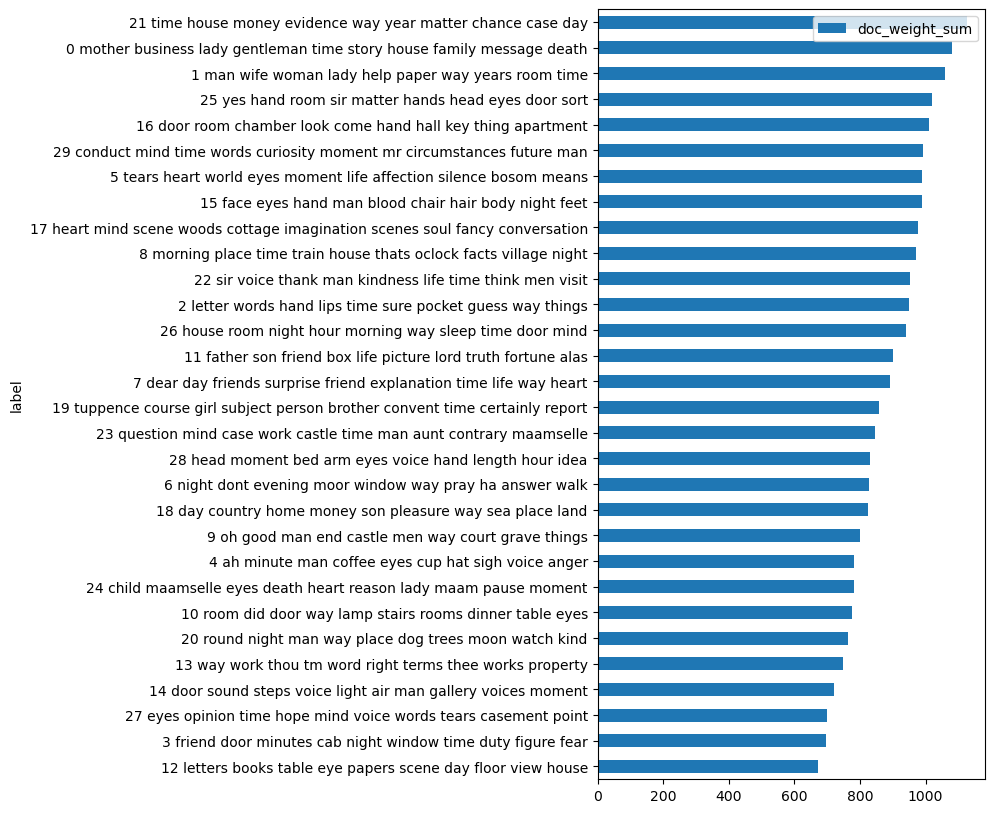

In [16]:
TOPICS.sort_values('doc_weight_sum', ascending=True).plot.barh(y='doc_weight_sum', x='label', figsize=(5,10)) 

## Explore Topics by Genre

In [17]:
topic_cols = [t for t in range(n_topics)]
GENRES = THETA.groupby('genre')[topic_cols].mean().T                                            
GENRES.index.name = 'topic_id'

In [18]:
GENRES.T

topic_id,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
genre,,,,,,,,,,,,,,,,,,,,,
d,0.045540,0.050608,0.045921,0.026614,0.033472,0.018092,0.032351,0.027425,0.048339,0.029422,...,0.027525,0.057933,0.034183,0.035337,0.023137,0.048049,0.039218,0.022271,0.027514,0.033073
g,0.034739,0.026547,0.023309,0.025943,0.024715,0.061774,0.028446,0.041783,0.022548,0.030951,...,0.029882,0.023757,0.037436,0.027136,0.037896,0.026417,0.030940,0.031767,0.036655,0.043437
nh,0.046962,0.051386,0.040670,0.027419,0.029726,0.019505,0.064890,0.022980,0.035608,0.036895,...,0.042234,0.038867,0.053321,0.047120,0.017716,0.046411,0.036156,0.019336,0.017636,0.022324


In [19]:
GENRES['topterms'] = TOPICS[[i for i in range(10)]].apply(lambda x: ' '.join(x), 1)

In [20]:
GENRES.sort_values('g', ascending=False).style.background_gradient()

genre,d,g,nh,topterms
topic_id,,,,
5,0.018092,0.061774,0.019505,tears heart world eyes moment life affection silence bosom means
17,0.017976,0.060730,0.019895,heart mind scene woods cottage imagination scenes soul fancy conversation
11,0.025003,0.045199,0.030005,father son friend box life picture lord truth fortune alas
29,0.033073,0.043437,0.022324,conduct mind time words curiosity moment mr circumstances future man
16,0.035141,0.042596,0.023552,door room chamber look come hand hall key thing apartment
7,0.027425,0.041783,0.022980,dear day friends surprise friend explanation time life way heart
24,0.023137,0.037896,0.017716,child maamselle eyes death heart reason lady maam pause moment
22,0.034183,0.037436,0.053321,sir voice thank man kindness life time think men visit
28,0.027514,0.036655,0.017636,head moment bed arm eyes voice hand length hour idea


In [21]:
import plotly.express as px

In [22]:
px.scatter(GENRES.reset_index(), 'g', 'd', hover_name='topterms', text='topic_id')\
    .update_traces(mode='text')

# Clutser Topics

In [23]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt

In [24]:
def plot_tree(tree, labels):
    plt.figure()
    fig, axes = plt.subplots(figsize=(5, 10))
    dendrogram = sch.dendrogram(tree, labels=labels, orientation="left")
    plt.tick_params(axis='both', which='major', labelsize=14)

In [25]:
SIMS = pdist(normalize(PHI), metric='euclidean')
TREE = sch.linkage(SIMS, method='ward')

In [26]:
labels  = ["{}: {}".format(a,b) for a, b in zip(GENRES.index,  GENRES.topterms.tolist())]

<Figure size 640x480 with 0 Axes>

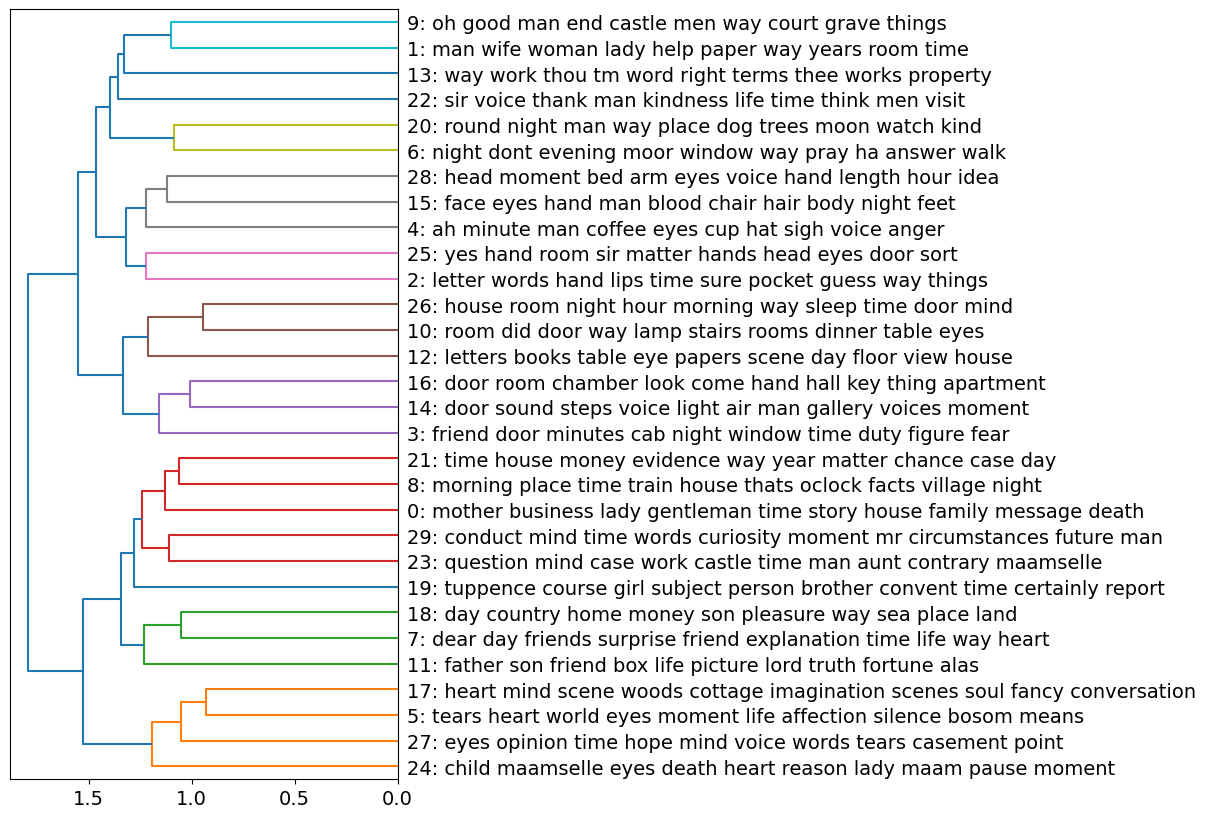

In [27]:
plot_tree(TREE, labels)

# Interpretation

## Notebook 1 (M08-1): Austen vs. Melville

**1. The notebook was run successfully with all outputs generated.**

**2. Topics most closely associated with each author:**

The two topics that most clearly separate the authors are **Topic 5** and **Topic 12**.

- **Austen's signature topic is Topic 5** (*mind, feelings, sister, time, family, father, mother, heart, man, manner*) with a mean weight of 0.215, compared to Melville's 0.022. This topic captures the social and emotional vocabulary of her novels: family relationships, interior psychological states, and interpersonal conduct. Her second-strongest topic (Topic 0: *time, sister, hour, party, evening, room, morning*) reinforces domestic routine and social gatherings.

- **Melville's signature topic is Topic 12** (*sea, ship, deck, water, head, air, mast, wind, night, boat*) with a mean weight of 0.073, compared to Austen's 0.009. This is clearly nautical/maritime vocabulary. His other top topics (Topic 7: *whale, boat, fish, whales, boats, sea*; Topic 18: *ship, captain, cabin, sailors, voyage, vessel*) further confirm this.

Austen writes about people navigating relationships; Melville writes about people navigating the ocean. The LDA model picks this up cleanly because these vocabularies barely overlap.

**3. Book-level model (OHCO changed to books):**

With only 20 documents (books) and 30 topics, the model degenerates. The majority of topics (~20 out of 30) collapse to the same set of low-frequency terms (e.g., "abandonment, population, poetry, poets, point, points, poison") that carry less interpretable meaning. The few surviving topics (e.g., T1: *time, man, day, sister, room*; T12: *sea, time, water, day, boat*; T18: *man, ship, whale, sea*) are broadly recognizable but much less specific than the paragraph-level topics.

The paragraph-level model is substantially more interpretable. This makes sense: LDA needs many documents to learn stable co-occurrence patterns.

---

## Notebook 2 (M08-2): Detective vs. Gothic Genres

**1. The "Explore Topics by Author" section was modified to group by genre instead of author.** Since the OHCO index already includes genre as the first level, the groupby simply changed from `THETA.groupby('author')` to `THETA.groupby('genre')`.

**2. The table and scatterplot now show topic associations for genres "g" (gothic) and "d" (detective).**

The topics most associated with each genre are:

- **Detective ("d")**: Topic 21 (*time, house, money, evidence, way, year, matter, chance, case, day*) at 0.058 vs. gothic's 0.024. Also Topic 8 (*morning, place, time, train, house, thats, oclock, facts, village*), Topic 1 (*man, wife, woman, lady, help, paper*), Topic 2 (*letter, words, hand, lips, time, sure, pocket, guess*), and Topic 25 (*yes, hand, room, sir, matter, hands, head, eyes*).

- **Gothic ("g")**: Topic 5 (*tears, heart, world, eyes, moment, life, affection, silence, bosom, means*) at 0.062 vs. detective's 0.018. Also Topic 17 (*heart, mind, scene, woods, cottage, imagination, scenes, soul, fancy, conversation*), Topic 11 (*father, son, friend, box, life, picture, lord, truth, fortune, alas*), and Topic 24 (*child, maamselle, eyes, death, heart, reason, lady*).

**3. Characterizing the genre difference:**

The detective genre's top topics are dominated by material and procedural language: evidence, money, facts, cases, letters, papers. The vocabulary is concrete and investigative — it concerns the observable world, clues, and logical reasoning. Even the domestic terms (house, room, morning, train, village) serve a forensic function: they are settings where evidence is found.

The gothic genre's top topics are dominated by emotional and psychological language: tears, heart, affection, silence, bosom, soul, imagination, fancy. The vocabulary is abstract and sentimental. The physical terms that do appear (woods, cottage, casement) evoke atmospheric landscapes rather than investigative settings.